# Unsupervised learning algos implementations

## Data setup

In [9]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

from utils.imports import *

In [13]:
# Generate sample data
x,y = make_blobs(n_samples=1500, n_features=3,centers=5,cluster_std=1,random_state=23)
range_n_clusters=[i for i in range(2,10)]

## KMeans

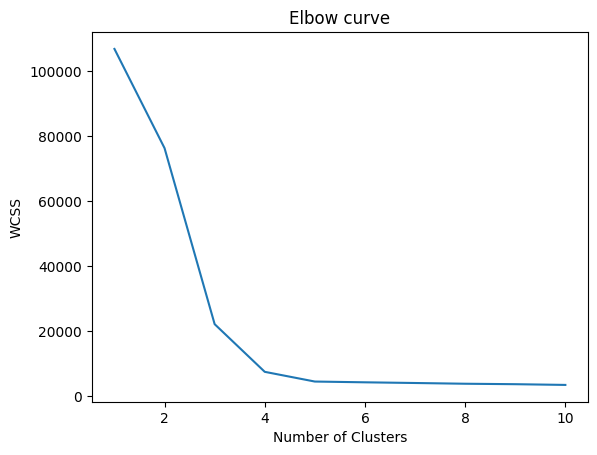

In [14]:
wcss=[] # within cluster sum of squares

for i in range(1,11):
    kmeans=KMeans(n_clusters=i,init='k-means++', random_state=23)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11),wcss)
plt.title('Elbow curve')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [15]:
clusterer= KMeans(n_clusters=4, random_state=13)
cluster_labels = clusterer.fit_predict(x)

## [Silhouette analysis](https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html)

For n_clusters = 2 The average silhouette_score is : 0.5423644387697171
For n_clusters = 3 The average silhouette_score is : 0.664827527456891
For n_clusters = 4 The average silhouette_score is : 0.7029892871562379
For n_clusters = 5 The average silhouette_score is : 0.5835127397386486
For n_clusters = 6 The average silhouette_score is : 0.5502356712895324
For n_clusters = 7 The average silhouette_score is : 0.48681325030229616
For n_clusters = 8 The average silhouette_score is : 0.3935500011951623
For n_clusters = 9 The average silhouette_score is : 0.2763666191711484


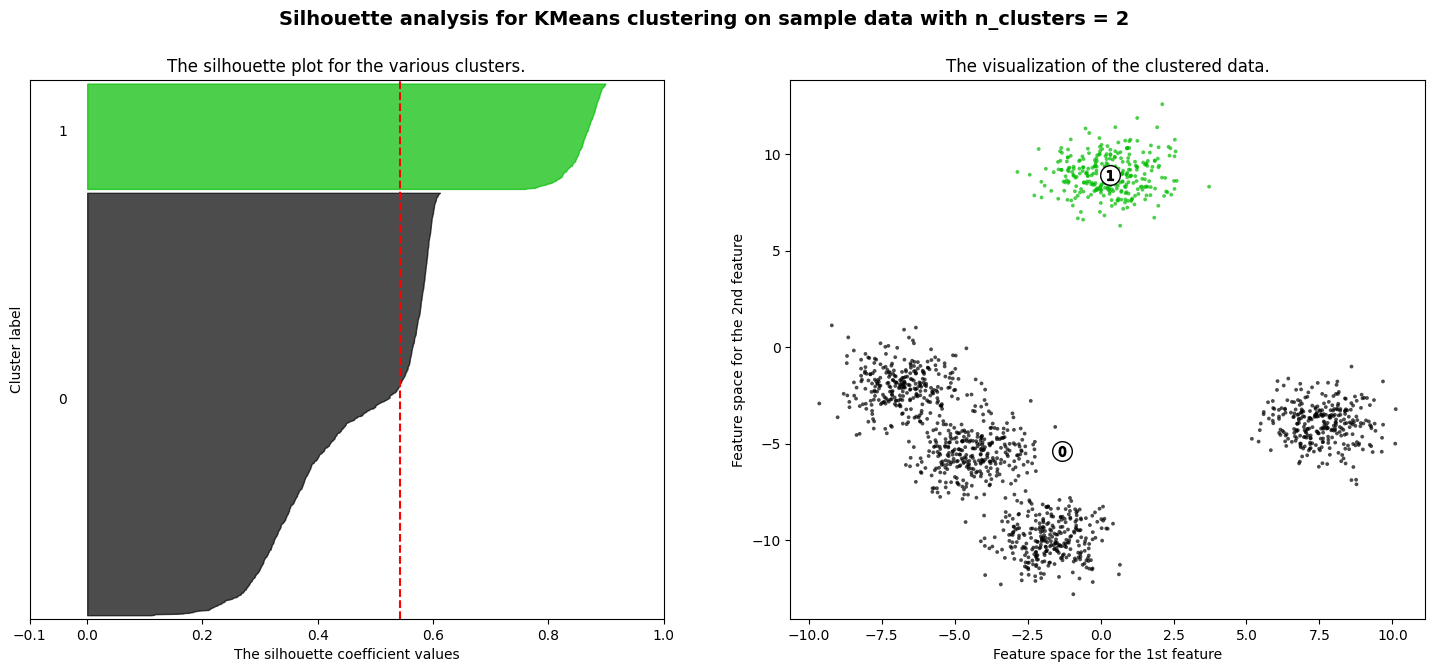

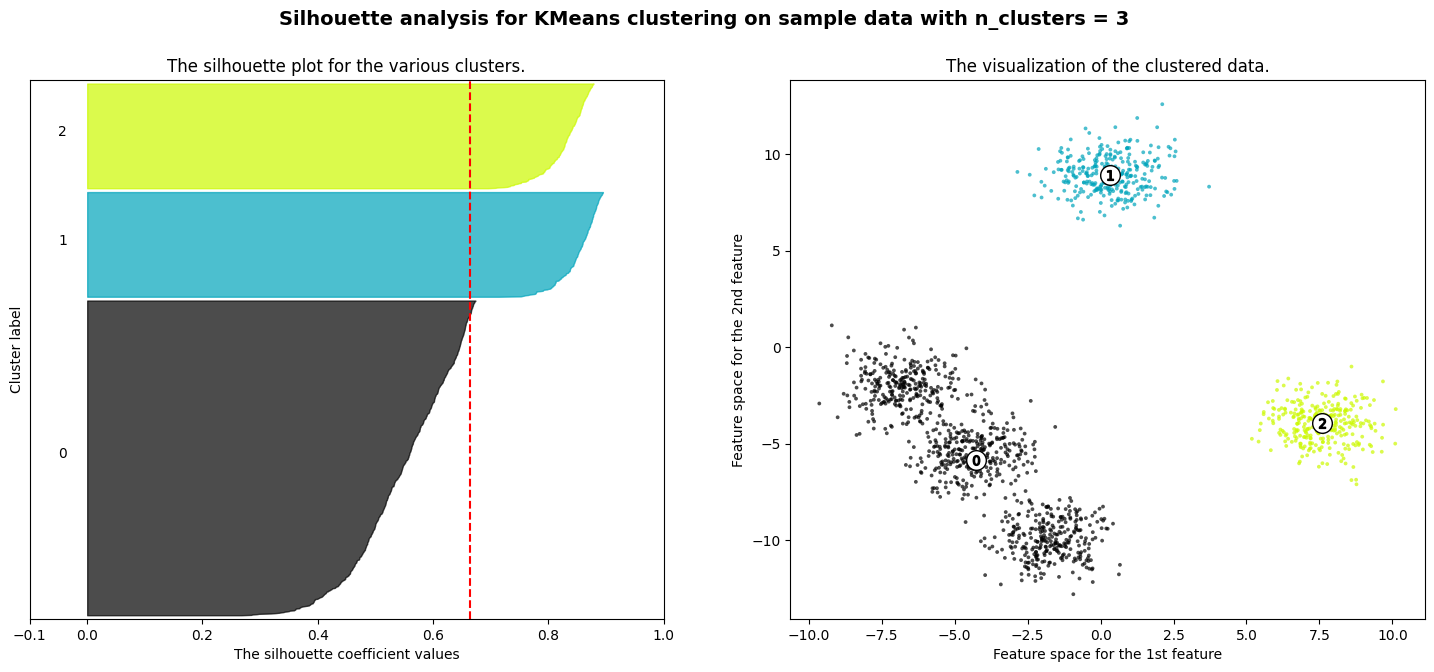

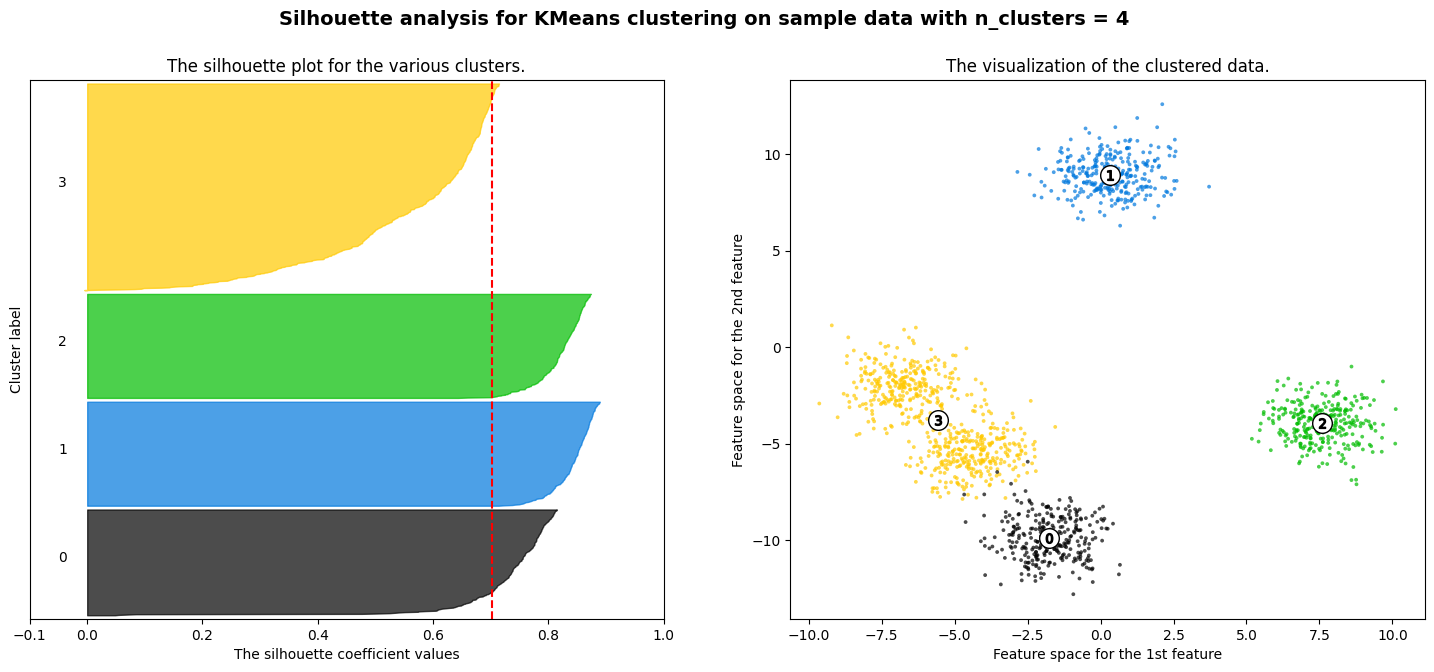

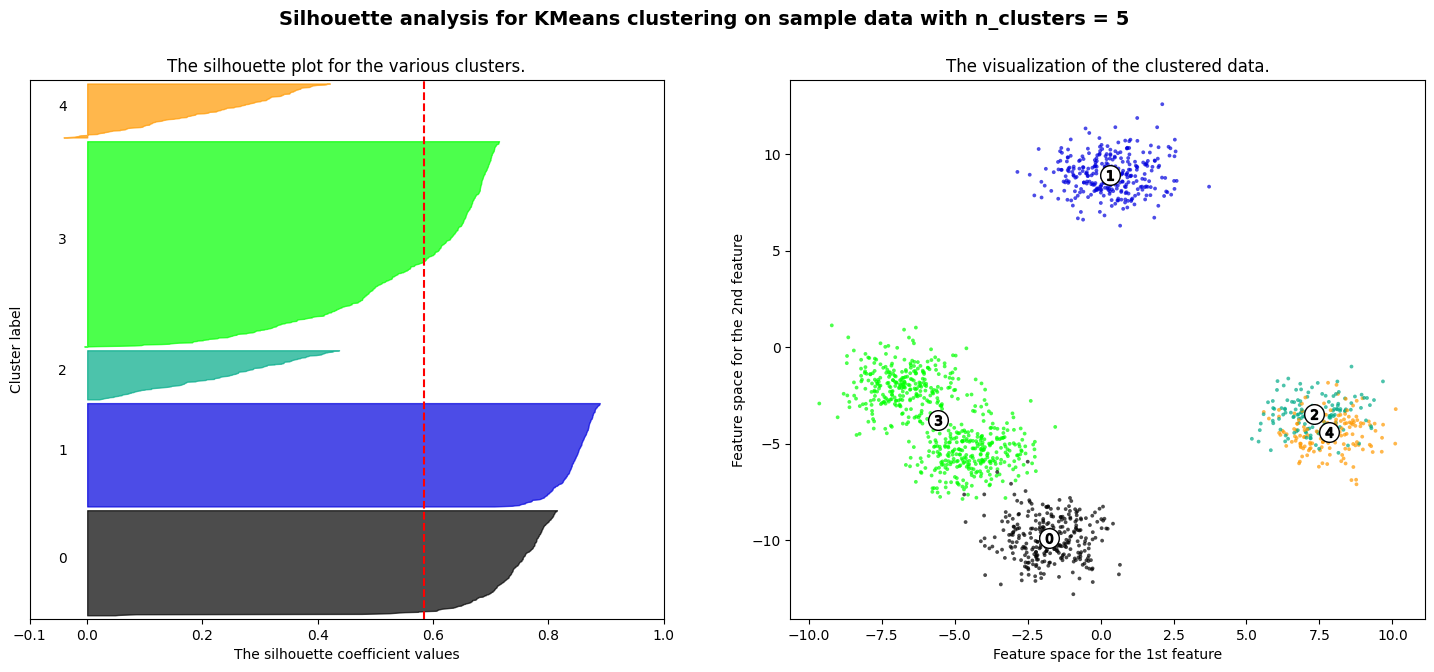

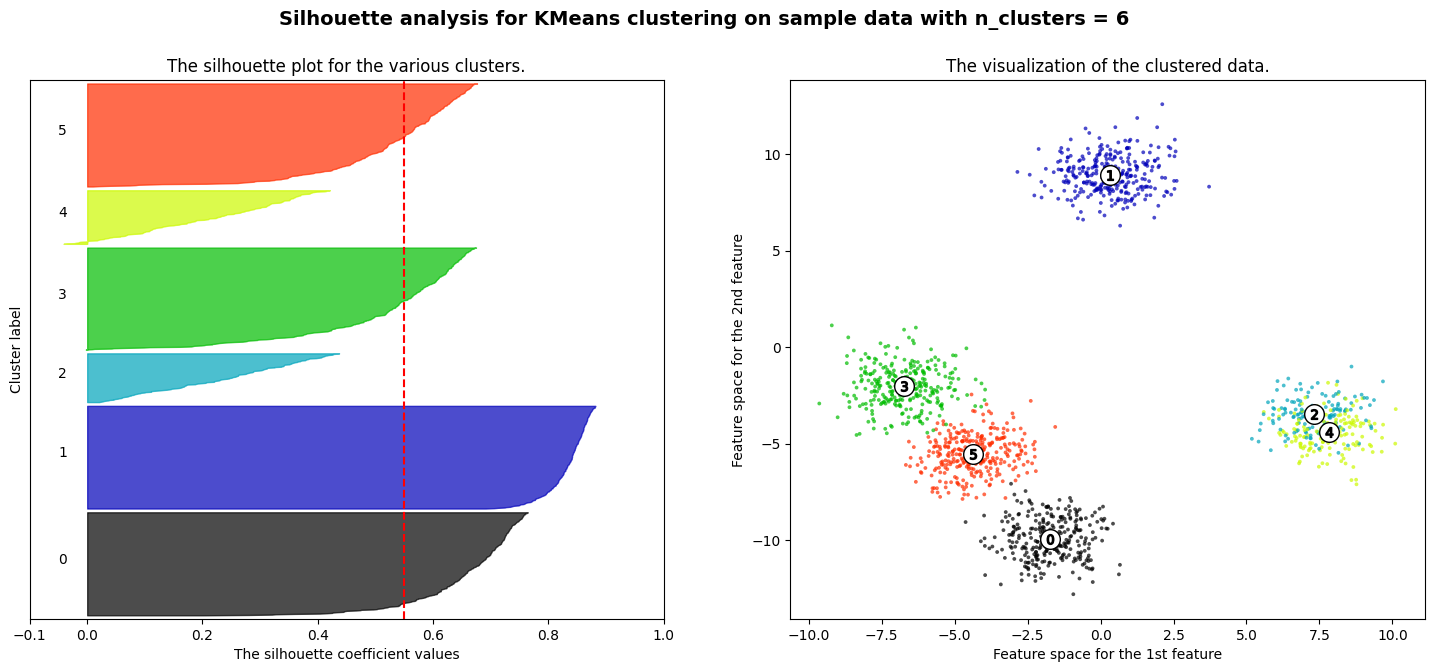

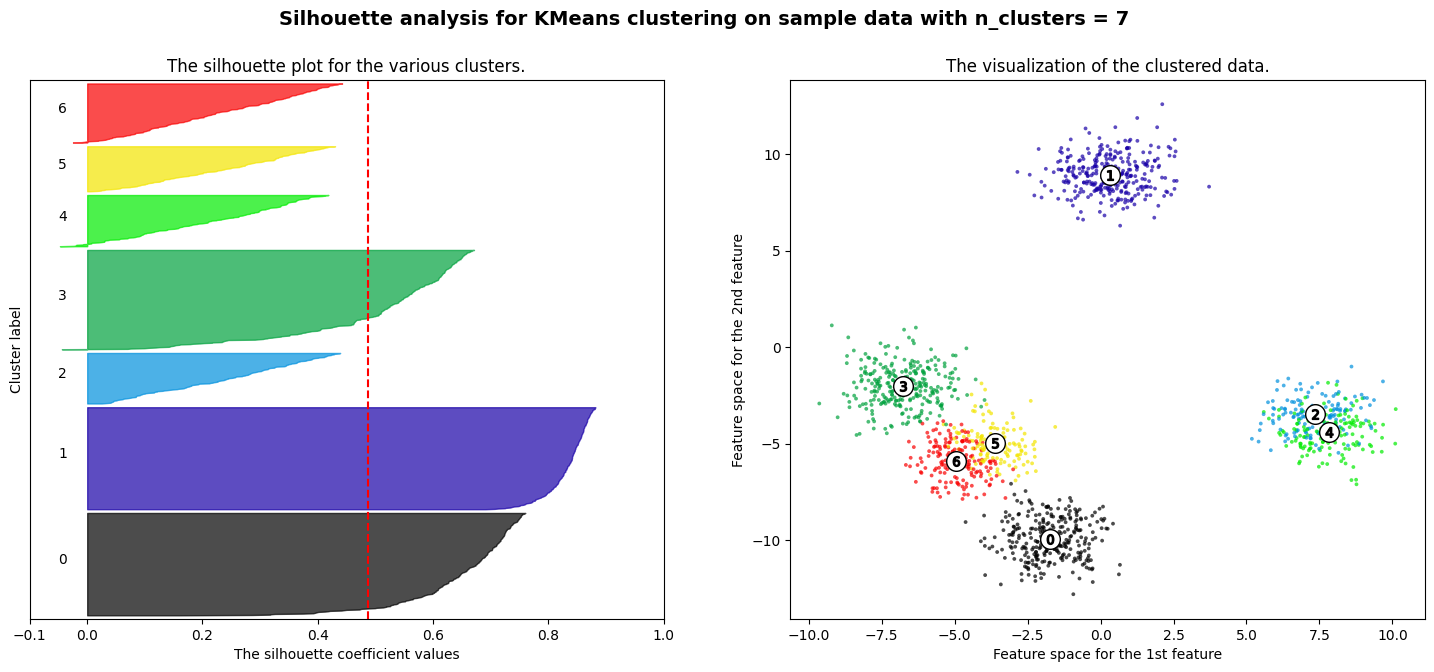

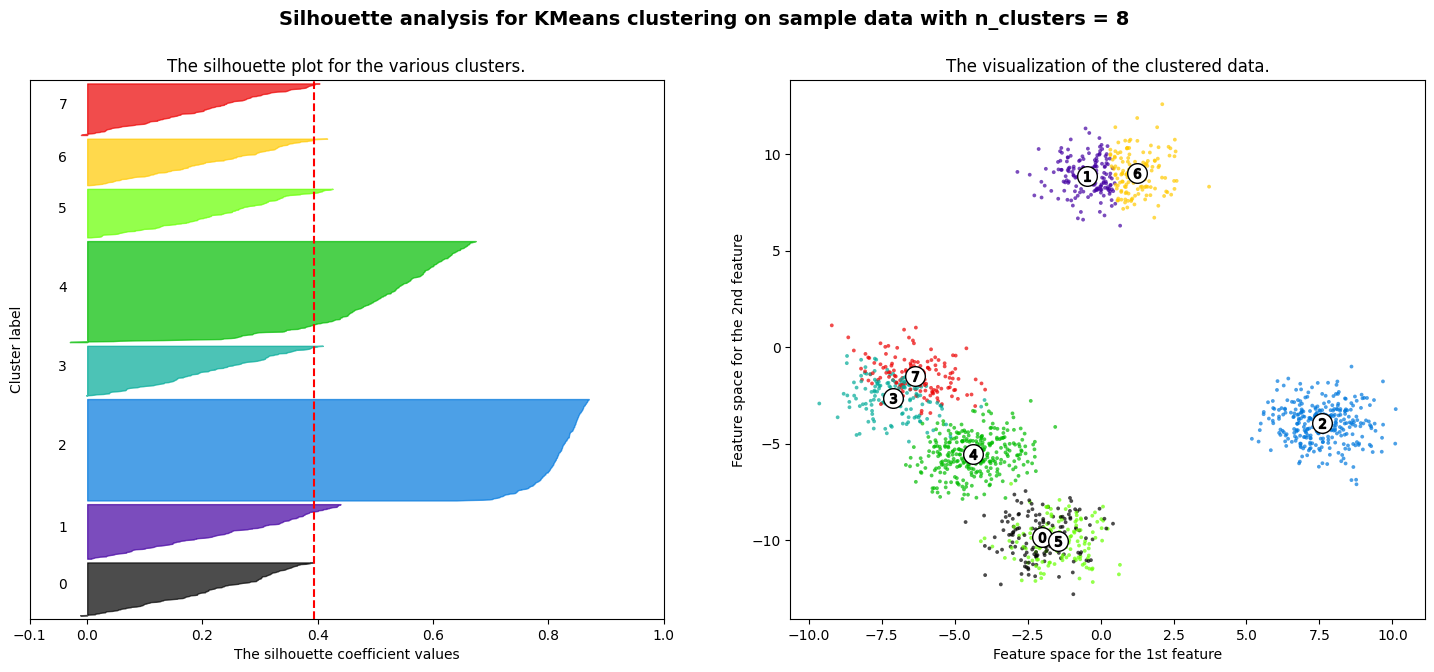

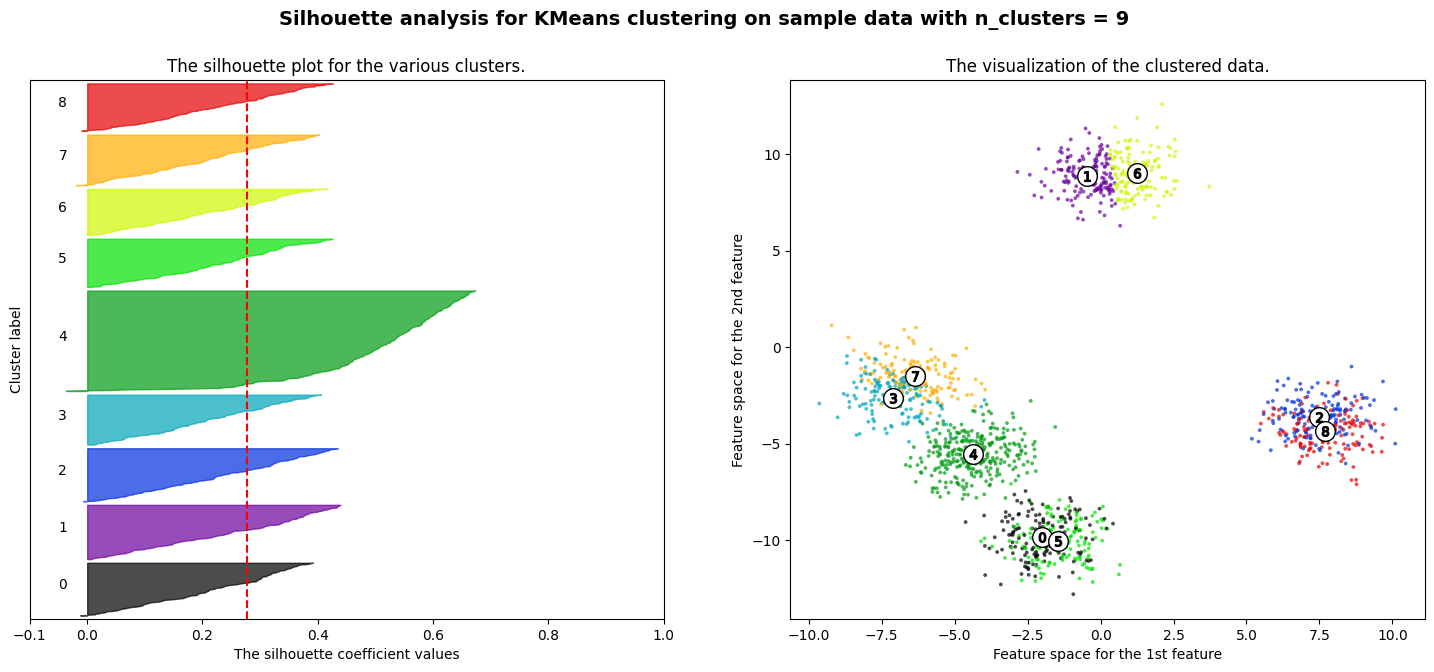

In [16]:
import matplotlib.cm as cm
for n_clusters in range_n_clusters:
    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(x) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    clusterer = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = clusterer.fit_predict(x)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(x, cluster_labels)
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_avg,
    )

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(x, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(
        x[:, 0], x[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
    )

    # Labeling the clusters
    centers = clusterer.cluster_centers_
    # Draw white circles at cluster centers
    ax2.scatter(
        centers[:, 0],
        centers[:, 1],
        marker="o",
        c="white",
        alpha=1,
        s=200,
        edgecolor="k",
    )

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(
        "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
        % n_clusters,
        fontsize=14,
        fontweight="bold",
    )

plt.show()

## DBScan

In [17]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.3, min_samples=10).fit(x)
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)


Estimated number of clusters: 0
Estimated number of noise points: 1500


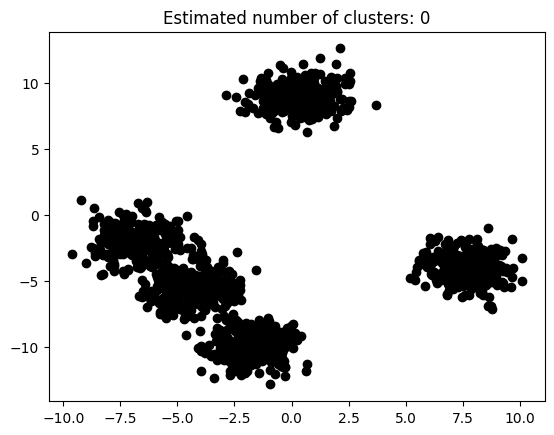

In [19]:
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = x[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    xy = x[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()

## Hyperparameter Tuning for DBSCAN (K-Distance Plot & Parameter Sweep)

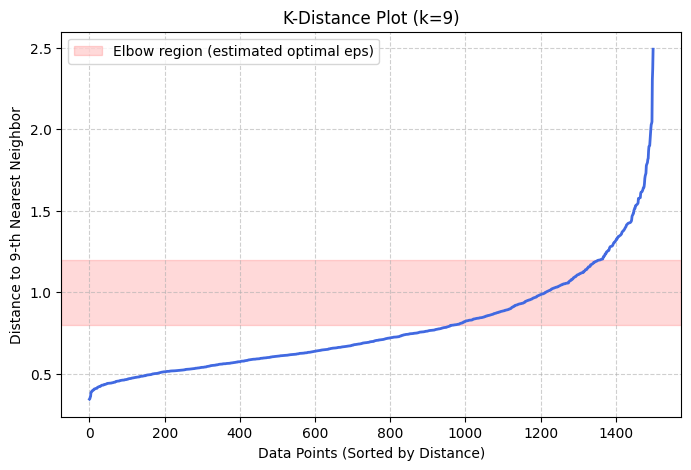

In [20]:
from sklearn.neighbors import NearestNeighbors

# 1. K-Distance Plot to estimate eps
# We set k = min_samples - 1 (here, min_samples=10, so k=9)
k = 9
neigh = NearestNeighbors(n_neighbors=k)
nbrs = neigh.fit(x)
distances, indices = nbrs.kneighbors(x)

# Sort the distances to the k-th nearest neighbor (column index k-1)
k_distances = np.sort(distances[:, k - 1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances, color='royalblue', lw=2)
plt.title(f"K-Distance Plot (k={k})")
plt.xlabel("Data Points (Sorted by Distance)")
plt.ylabel(f"Distance to {k}-th Nearest Neighbor")
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhspan(0.8, 1.2, color='red', alpha=0.15, label='Elbow region (estimated optimal eps)')
plt.legend()
plt.show()

In [25]:
# 2. Grid Search / Parameter Sweep using Silhouette Score
from sklearn.metrics import silhouette_score

eps_grid = np.arange(0.3, 1.5, 0.1)
min_samples_grid = [5, 6, 10, 15, 20]

best_score = -1
best_params = None

print("--- Starting Grid Sweep ---")
for eps in eps_grid:
    for min_samples in min_samples_grid:
        db = DBSCAN(eps=eps, min_samples=min_samples).fit(x)
        labels = db.labels_
        
        unique_labels = set(labels)
        n_clusters = len(unique_labels) - (1 if -1 in labels else 0)
        
        if n_clusters > 1:
            score = silhouette_score(x, labels)
            print(f"eps={eps:.1f}, min_samples={min_samples} -> clusters={n_clusters}, Silhouette={score:.3f}")
            if score > best_score:
                best_score = score
                best_params = {'eps': eps, 'min_samples': min_samples}
        else:
            print(f"eps={eps:.1f}, min_samples={min_samples} -> Less than 2 clusters found. Skipping.")

print("\nBest Parameters:", best_params)
print("Best Silhouette Score:", best_score)

# 3. Run DBSCAN with the optimal parameters found
if best_params is not None:
    db_opt = DBSCAN(eps=best_params['eps'], min_samples=best_params['min_samples']).fit(x)
    opt_labels = db_opt.labels_
    opt_clusters = len(set(opt_labels)) - (1 if -1 in opt_labels else 0)
    print(f"\nOptimal DBSCAN configured with eps={best_params['eps']:.1f} yields {opt_clusters} clusters.")

--- Starting Grid Sweep ---
eps=0.3, min_samples=5 -> clusters=14, Silhouette=-0.706
eps=0.3, min_samples=6 -> clusters=9, Silhouette=-0.726
eps=0.3, min_samples=10 -> Less than 2 clusters found. Skipping.
eps=0.3, min_samples=15 -> Less than 2 clusters found. Skipping.
eps=0.3, min_samples=20 -> Less than 2 clusters found. Skipping.
eps=0.4, min_samples=5 -> clusters=38, Silhouette=-0.487
eps=0.4, min_samples=6 -> clusters=26, Silhouette=-0.575
eps=0.4, min_samples=10 -> clusters=2, Silhouette=-0.341
eps=0.4, min_samples=15 -> Less than 2 clusters found. Skipping.
eps=0.4, min_samples=20 -> Less than 2 clusters found. Skipping.
eps=0.5, min_samples=5 -> clusters=30, Silhouette=-0.346
eps=0.5, min_samples=6 -> clusters=18, Silhouette=-0.334
eps=0.5, min_samples=10 -> clusters=16, Silhouette=-0.484
eps=0.5, min_samples=15 -> clusters=3, Silhouette=-0.349
eps=0.5, min_samples=20 -> Less than 2 clusters found. Skipping.
eps=0.6, min_samples=5 -> clusters=8, Silhouette=0.216
eps=0.6, min_s

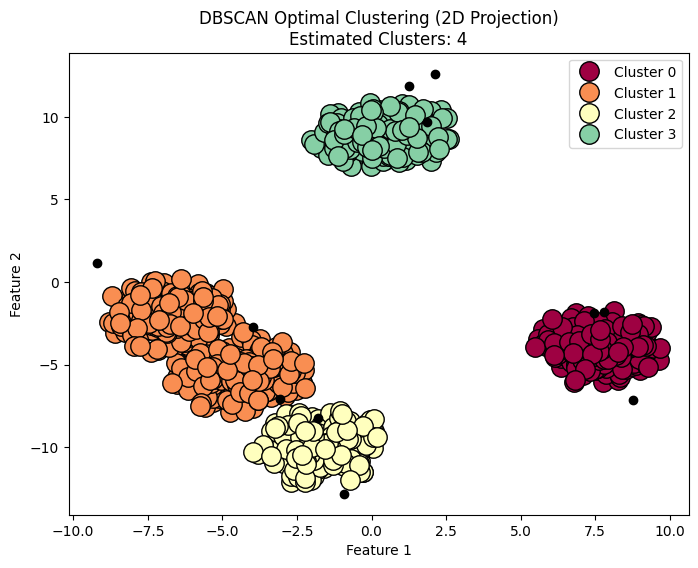

In [23]:
fig, ax = plt.subplots(figsize=(8, 6))
unique_labels = set(opt_labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
core_samples_mask = np.zeros_like(opt_labels, dtype=bool)
core_samples_mask[db_opt.core_sample_indices_] = True
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]
    class_member_mask = (opt_labels == k)

    # Plot core samples (larger marker size)
    xy_core = x[class_member_mask & core_samples_mask]
    if len(xy_core) > 0:
        ax.plot(
            xy_core[:, 0],
    xy_core[:, 1],
    "o",
    markerfacecolor=tuple(col),
    markeredgecolor="k",
    markersize=14,
    label=f'Cluster {k}' if k != -1 else 'Noise'
        )

# Plot non-core samples / outliers (smaller marker size)
xy_non_core = x[class_member_mask & ~core_samples_mask]
if len(xy_non_core) > 0:
        ax.plot(
    xy_non_core[:, 0],
    xy_non_core[:, 1],
    "o",
    markerfacecolor=tuple(col),
    markeredgecolor="k",
    markersize=6,
        )

plt.title(f"DBSCAN Optimal Clustering (2D Projection)\nEstimated Clusters: {opt_clusters}")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

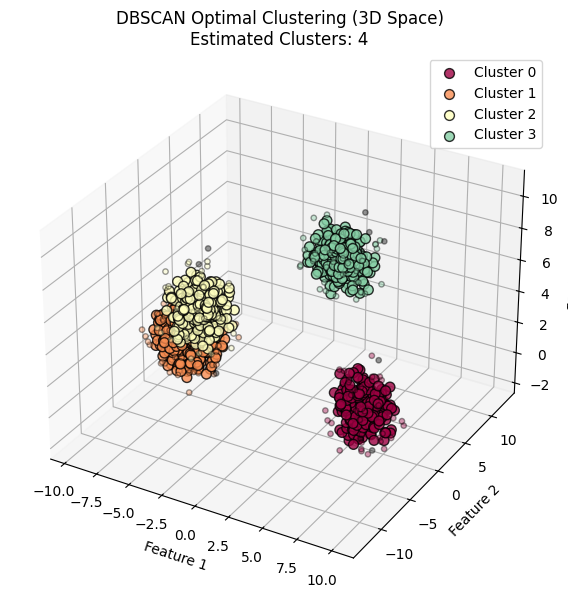

In [24]:
# 4. Plotting the optimal clusters in 3D as we have 3-dimensional data luckily
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

unique_labels = set(opt_labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

core_samples_mask = np.zeros_like(opt_labels, dtype=bool)
core_samples_mask[db_opt.core_sample_indices_] = True

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black color for noise points
        col = [0, 0, 0, 1]

    class_member_mask = (opt_labels == k)

    # Plot core samples (larger marker size)
    xy_core = x[class_member_mask & core_samples_mask]
    if len(xy_core) > 0:
        ax.scatter(
            xy_core[:, 0],
            xy_core[:, 1],
            xy_core[:, 2],
            c=[col],
            edgecolors='k',
            s=50,
            alpha=0.8,
            label=f'Cluster {k}' if k != -1 else 'Noise'
        )

    # Plot non-core samples / outliers (smaller marker size)
    xy_non_core = x[class_member_mask & ~core_samples_mask]
    if len(xy_non_core) > 0:
        ax.scatter(
            xy_non_core[:, 0],
            xy_non_core[:, 1],
            xy_non_core[:, 2],
            c=[col],
            edgecolors='k',
            s=15,
            alpha=0.4
        )

ax.set_title(f"DBSCAN Optimal Clustering (3D Space)\nEstimated Clusters: {opt_clusters}")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("Feature 3")
plt.legend()
plt.show()

## K-Means Limitation: The Donut Shape
K-Means assumes clusters are convex and spherical. It fails to capture complex shapes like concentric circles.

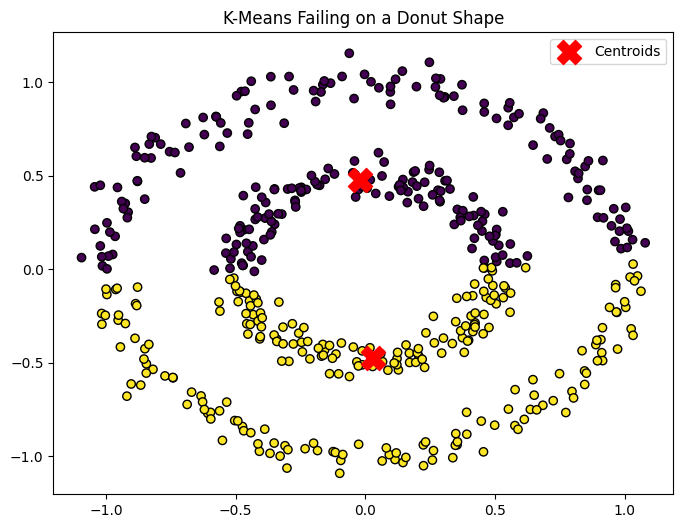

In [26]:
from sklearn.datasets import make_circles
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Generate the Donut Data
X_circles, y_circles = make_circles(n_samples=500, factor=0.5, noise=0.05, random_state=42)

# 2. Apply K-Means (Trying to find 2 clusters)
kmeans_donut = KMeans(n_clusters=2, random_state=42)
kmeans_donut_labels = kmeans_donut.fit_predict(X_circles)

# 3. Plot the result
plt.figure(figsize=(8, 6))
plt.scatter(X_circles[:, 0], X_circles[:, 1], c=kmeans_donut_labels, cmap='viridis', edgecolors='k')
plt.scatter(kmeans_donut.cluster_centers_[:, 0], kmeans_donut.cluster_centers_[:, 1], s=300, c='red', marker='X', label='Centroids')
plt.title("K-Means Failing on a Donut Shape")
plt.legend()
plt.show()

## [Comparison between KMeans and DBScan](https://www.datacamp.com/tutorial/dbscan-clustering-algorithm)